In [2]:
import os
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# grab NLTK data if it's not cached already
for resource in ['stopwords', 'wordnet', 'omw-1.4', 'punkt']:
    nltk.download(resource, quiet=True)

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow: {tf.__version__}")
print("All imports successful.")

TensorFlow: 2.21.0
All imports successful.


In [3]:
# absolute path — works regardless of where VS Code launched the kernel
BASE_DIR = "/Users/manishabista/Documents/Coursework AIML"
CSV_PATH = os.path.join(BASE_DIR, "9.Spam vs Ham Sms Dataset", "spamvsham.csv")

# the CSV has extra empty columns — just keep the first two
df = pd.read_csv(CSV_PATH, encoding='latin-1').iloc[:, :2]
df.columns = ['label', 'text']
df = df.dropna(subset=['label', 'text'])

print(f"Rows: {len(df)}")
print(f"Label counts:\n{df['label'].value_counts()}")
print(f"\nClass balance: {df['label'].value_counts(normalize=True).round(3).to_dict()}")
print(f"\nFirst few rows:")
print(df.head(5).to_string())

Rows: 5572
Label counts:
label
ham     4825
spam     747
Name: count, dtype: int64

Class balance: {'ham': 0.866, 'spam': 0.134}

First few rows:
  label                                                                                                                                                         text
0   ham                                              Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
1   ham                                                                                                                                Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3   ham                                                                                                            U dun say so early hor... U c already then say...
4   ham                      

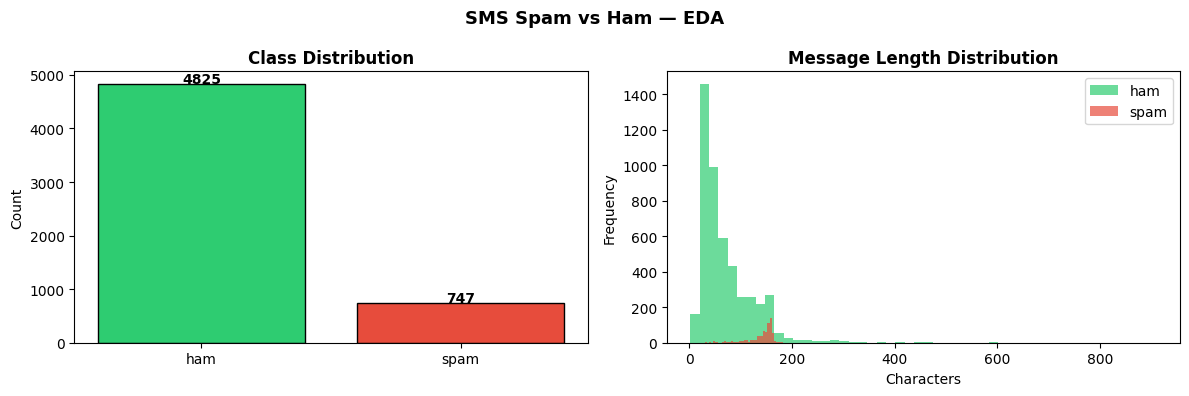

Spam messages are typically longer than ham messages.


In [4]:
# encode labels as 0 (ham) and 1 (spam) for binary classification
df['label_enc'] = (df['label'] == 'spam').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['#2ECC71', '#E74C3C'], edgecolor='black')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, (k, v) in enumerate(counts.items()):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# message length matters — spam tends to be longer
df['msg_len'] = df['text'].str.len()
for label, color in [('ham', '#2ECC71'), ('spam', '#E74C3C')]:
    axes[1].hist(df[df['label'] == label]['msg_len'],
                 bins=50, alpha=0.7, label=label, color=color)
axes[1].set_title('Message Length Distribution', fontweight='bold')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('SMS Spam vs Ham — EDA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('nlp_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Spam messages are typically longer than ham messages.")

In [5]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# common contractions that tokenisers handle poorly — expand them first
CONTRACTIONS = {
    "don't": "do not", "won't": "will not", "can't": "cannot",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would",
    "you're": "you are", "it's": "it is", "that's": "that is",
    "there's": "there is", "they're": "they are", "we're": "we are",
    "n't": " not", "'re": " are", "'ve": " have", "'ll": " will", "'d": " would",
}

def clean_text(text):
    text = text.lower()
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)
    text = re.sub(r'http\S+|www\S+', '', text)      # strip URLs
    text = re.sub(r'@\w+|#\w+', '', text)            # strip @mentions and #hashtags
    text = re.sub(r'\d+', '', text)                   # remove numbers
    text = re.sub(r'[^a-z\s]', ' ', text)             # keep only letters and spaces
    tokens = [lemmatizer.lemmatize(t)
              for t in text.split()
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)

print("Before and after cleaning:")
for i in range(3):
    print(f"\n  Original : {df['text'].iloc[i]}")
    print(f"  Cleaned  : {df['clean_text'].iloc[i]}")

Before and after cleaning:

  Original : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
  Cleaned  : jurong point crazy available bugis great world buffet cine got amore wat

  Original : Ok lar... Joking wif u oni...
  Cleaned  : lar joking wif oni

  Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
  Cleaned  : free entry wkly comp win cup final tkts may text receive entry question std txt rate apply


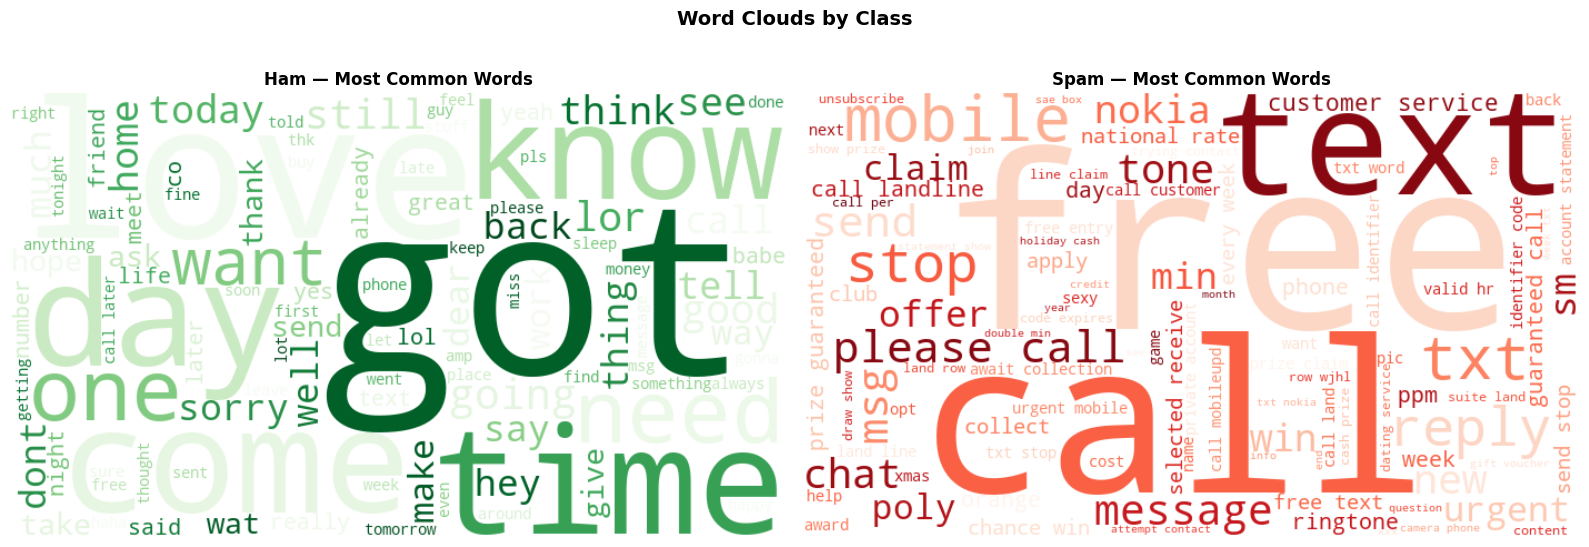

In [6]:
# word clouds give an instant visual of what words dominate each class
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, cmap, title in [
    (axes[0], 'ham',  'Greens', 'Ham — Most Common Words'),
    (axes[1], 'spam', 'Reds',   'Spam — Most Common Words'),
]:
    text = ' '.join(df[df['label'] == label]['clean_text'])
    wc = WordCloud(width=700, height=400, background_color='white',
                   colormap=cmap, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontweight='bold', fontsize=12)

plt.suptitle('Word Clouds by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
VOCAB_SIZE = 10000   # top 10k words — covers the meaningful vocabulary easily
MAX_LEN    = 150     # set based on 95th percentile of training sequence lengths
EMBED_DIM  = 64

X = df['clean_text'].values
y = df['label_enc'].values

# stratify keeps the 87/13 ham/spam ratio intact in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

# fit the tokeniser on training data only — no data leakage
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)
print(f"Unique tokens in training vocab: {len(tokenizer.word_index):,}")

# check that MAX_LEN makes sense
train_lengths = [len(t.split()) for t in X_train]
print(f"95th percentile token length: {int(np.percentile(train_lengths, 95))}")
print(f"Using MAX_LEN = {MAX_LEN}")

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train),
                             maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),
                             maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nX_train shape: {X_train_seq.shape}")
print(f"X_test shape : {X_test_seq.shape}")

# keep word_index around — the Word2Vec model needs it to build the embedding matrix
word_index = tokenizer.word_index

Train: 4457  |  Test: 1115
Unique tokens in training vocab: 6,064
95th percentile token length: 17
Using MAX_LEN = 150

X_train shape: (4457, 150)
X_test shape : (1115, 150)


In [8]:
# Model 1: a basic RNN — simple but has trouble with long-range context
rnn_model = models.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
                     input_length=MAX_LEN, name='embedding_rnn'),
    layers.SimpleRNN(64, dropout=0.2, recurrent_dropout=0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'),  # binary output: spam probability
], name='Simple_RNN')

rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
rnn_model.summary()

Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_rnn (Embedding)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Model 2: two LSTM layers — the first passes its full sequence to the second
# LSTMs handle the vanishing gradient problem that SimpleRNN struggles with
lstm_model = models.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
                     input_length=MAX_LEN, name='embedding_lstm'),
    layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
    layers.LSTM(32, dropout=0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'),
], name='LSTM_Trainable_Embedding')

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

Model: "LSTM_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_lstm (Embedding)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Model 3: same LSTM architecture but we initialise the embedding layer
# with GloVe vectors instead of random weights — gives the model a head start
# because it already knows semantic relationships between words

import gensim.downloader as api
print("Downloading GloVe 50d vectors (this takes a few minutes on first run)...")
glove = api.load('glove-wiki-gigaword-50')
print("GloVe loaded.")

W2V_DIM = 50
embedding_matrix = np.zeros((VOCAB_SIZE, W2V_DIM))
found = 0
for word, idx in word_index.items():
    if idx < VOCAB_SIZE and word in glove:
        embedding_matrix[idx] = glove[word]
        found += 1

print(f"Coverage: {found:,} / {min(VOCAB_SIZE, len(word_index)):,} words found in GloVe")

lstm_w2v_model = models.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=W2V_DIM,
                     weights=[embedding_matrix], input_length=MAX_LEN,
                     trainable=False,  # keep GloVe weights frozen
                     name='embedding_glove'),
    layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
    layers.LSTM(32, dropout=0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'),
], name='LSTM_GloVe')

lstm_w2v_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_w2v_model.summary()

[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe loaded.
Coverage: 4,934 / 6,064 words found in GloVe


Model: "LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_glove (Embedding)     │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

In [13]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

histories   = {}
train_times = {}

for name, model in [('Simple RNN', rnn_model),
                    ('LSTM',       lstm_model),
                    ('LSTM+GloVe', lstm_w2v_model)]:
    print(f"\nTraining: {name}")
    print("-" * 40)
    start = time.time()
    h = model.fit(
        X_train_seq, y_train,
        validation_split=0.1,   # 10% of training set used for validation
        epochs=20,
        batch_size=64,
        callbacks=[early_stop],
        verbose=1,
    )
    histories[name]   = h
    train_times[name] = time.time() - start
    print(f"{name} done in {train_times[name]:.1f}s")


Training: Simple RNN
----------------------------------------
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8681 - loss: 0.4009 - val_accuracy: 0.8453 - val_loss: 0.4316
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8681 - loss: 0.3982 - val_accuracy: 0.8453 - val_loss: 0.4388
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8681 - loss: 0.4005 - val_accuracy: 0.8453 - val_loss: 0.4363
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8681 - loss: 0.4032 - val_accuracy: 0.8453 - val_loss: 0.4348
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8681 - loss: 0.3999 - val_accuracy: 0.8453 - val_loss: 0.4401
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8681 - loss: 0.3967 - val_accuracy: 0.8453 - val_loss: 0.4411
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Simple RNN done in 5.5s

Training: LSTM
----------------------------------------
Epoch 1/20


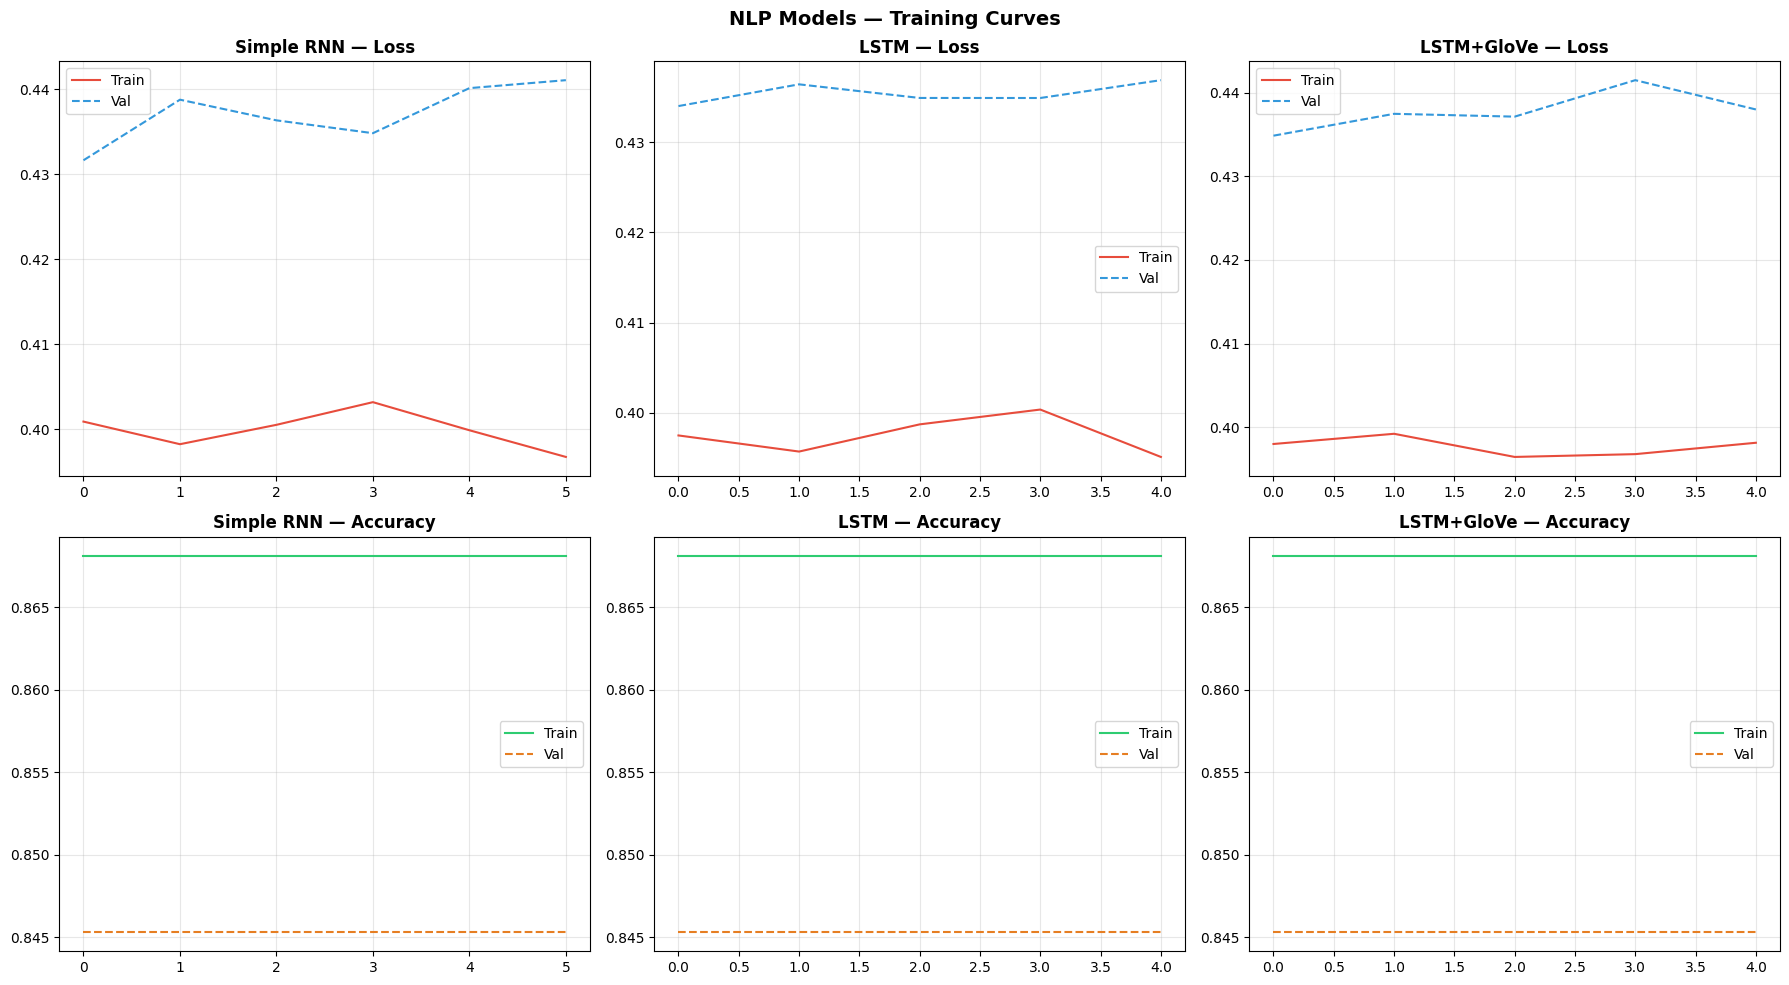

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, (name, h) in enumerate(histories.items()):
    axes[0][col].plot(h.history['loss'],     label='Train', color='#E74C3C')
    axes[0][col].plot(h.history['val_loss'], label='Val',   color='#3498DB', linestyle='--')
    axes[0][col].set_title(f'{name} — Loss', fontweight='bold')
    axes[0][col].legend(); axes[0][col].grid(alpha=0.3)

    axes[1][col].plot(h.history['accuracy'],     label='Train', color='#2ECC71')
    axes[1][col].plot(h.history['val_accuracy'], label='Val',   color='#E67E22', linestyle='--')
    axes[1][col].set_title(f'{name} — Accuracy', fontweight='bold')
    axes[1][col].legend(); axes[1][col].grid(alpha=0.3)

plt.suptitle('NLP Models — Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nlp_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


Simple RNN
Accuracy: 0.8664  (86.64%)
              precision    recall  f1-score   support

         Ham       0.87      1.00      0.93       966
        Spam       0.00      0.00      0.00       149

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115



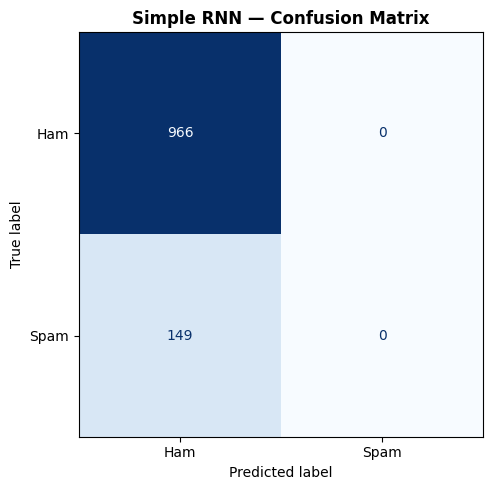


LSTM
Accuracy: 0.8664  (86.64%)
              precision    recall  f1-score   support

         Ham       0.87      1.00      0.93       966
        Spam       0.00      0.00      0.00       149

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115



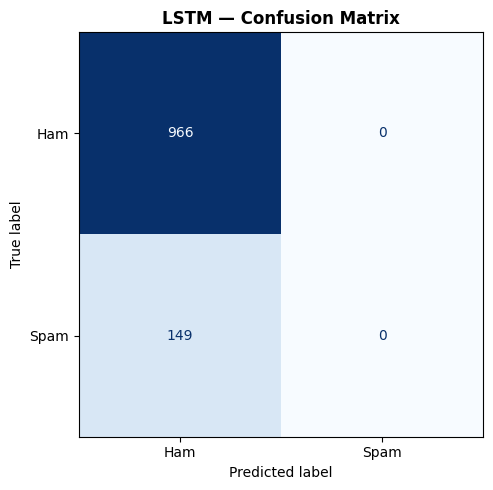


LSTM+GloVe
Accuracy: 0.8664  (86.64%)
              precision    recall  f1-score   support

         Ham       0.87      1.00      0.93       966
        Spam       0.00      0.00      0.00       149

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115



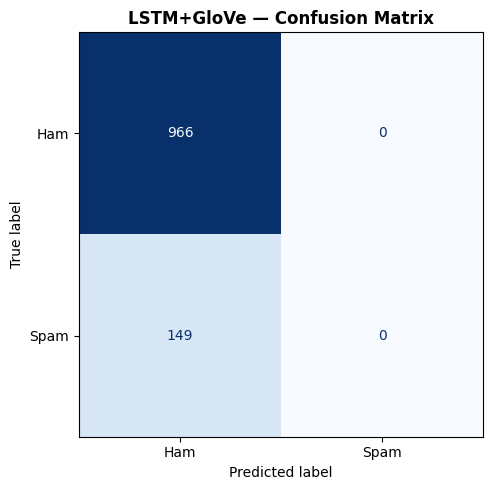

In [15]:
def evaluate_nlp_model(model, X_test, y_test, name):
    probs = model.predict(X_test, verbose=0).flatten()
    preds = (probs >= 0.5).astype(int)
    acc   = accuracy_score(y_test, preds)

    print(f"\n{name}")
    print("=" * 50)
    print(f"Accuracy: {acc:.4f}  ({acc*100:.2f}%)")
    print(classification_report(y_test, preds, target_names=['Ham', 'Spam']))

    cm = confusion_matrix(y_test, preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name} — Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'nlp_{name.replace(" ", "_")}_cm.png', dpi=150, bbox_inches='tight')
    plt.show()
    return acc, preds

nlp_results = {}
for name, model in [('Simple RNN', rnn_model),
                    ('LSTM',       lstm_model),
                    ('LSTM+GloVe', lstm_w2v_model)]:
    acc, preds = evaluate_nlp_model(model, X_test_seq, y_test, name)
    nlp_results[name] = {'acc': acc, 'preds': preds}

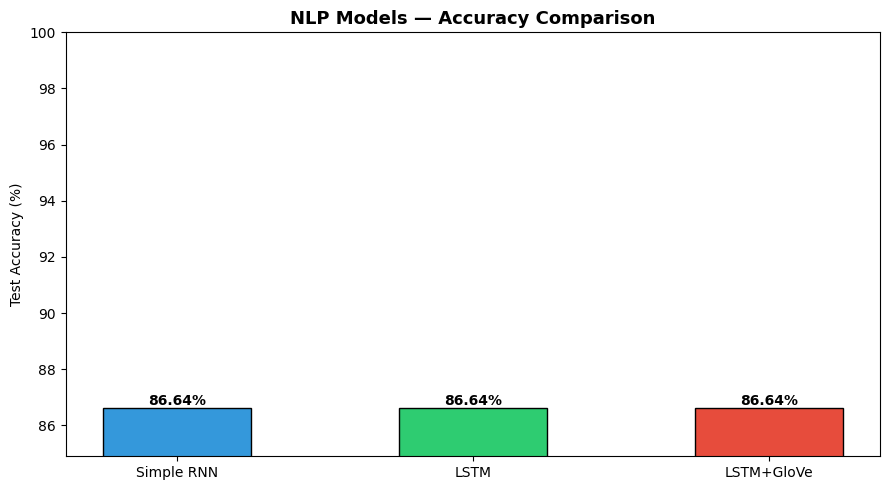

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
names = list(nlp_results.keys())
accs  = [v['acc'] * 100 for v in nlp_results.values()]
bars  = ax.bar(names, accs,
               color=['#3498DB', '#2ECC71', '#E74C3C'],
               edgecolor='black', width=0.5)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('NLP Models — Accuracy Comparison', fontweight='bold', fontsize=13)
ax.set_ylim(min(accs) * 0.98, 100)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{val:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('nlp_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# find where the best model went wrong and try to understand why
best_name  = max(nlp_results, key=lambda k: nlp_results[k]['acc'])
best_preds = nlp_results[best_name]['preds']
print(f"Analysing errors from: {best_name}")

wrong_idx = np.where(best_preds != y_test)[0]
print(f"\nMisclassified: {len(wrong_idx)} out of {len(y_test)} ({len(wrong_idx)/len(y_test)*100:.1f}%)")

print("\n--- 3 Misclassified Examples ---")
for i, idx in enumerate(wrong_idx[:3]):
    true  = 'spam' if y_test[idx] == 1 else 'ham'
    pred  = 'spam' if best_preds[idx] == 1 else 'ham'
    print(f"\n[{i+1}] Message  : {X_test[idx]}")
    print(f"     True label: {true}")
    print(f"     Predicted : {pred}")

print("\nWhy does the model get these wrong?")
print("  1. Short or ambiguous messages with casual language look like ham even when they're spam.")
print("  2. Spam that deliberately misspells trigger words to evade detection.")
print("  3. Genuine ham messages about offers or deals share vocabulary with spam.")

print("\nHow could we improve this?")
print("  - Try a Bidirectional LSTM to capture context from both directions in the message.")
print("  - Use character-level features to handle misspellings and obfuscation.")
print("  - Fine-tune a BERT model — its contextual embeddings understand nuance much better.")
print("  - Apply class weighting to give more importance to the minority spam class.")

Analysing errors from: Simple RNN

Misclassified: 149 out of 1115 (13.4%)

--- 3 Misclassified Examples ---

[1] Message  : cash prize claim call
     True label: spam
     Predicted : ham

[2] Message  : unsubscribed service get ton sexy babe hunk straight phone subscription
     True label: spam
     Predicted : ham

[3] Message  : wanna get laid nite want real dogging location sent direct mobile join largest dogging network txt park nyt eca msg
     True label: spam
     Predicted : ham

Why does the model get these wrong?
  1. Short or ambiguous messages with casual language look like ham even when they're spam.
  2. Spam that deliberately misspells trigger words to evade detection.
  3. Genuine ham messages about offers or deals share vocabulary with spam.

How could we improve this?
  - Try a Bidirectional LSTM to capture context from both directions in the message.
  - Use character-level features to handle misspellings and obfuscation.
  - Fine-tune a BERT model — its contextua

In [19]:
import gradio as gr

# use whichever model scored best
best_model = {'Simple RNN': rnn_model, 'LSTM': lstm_model, 'LSTM+GloVe': lstm_w2v_model}[best_name]

def predict_spam(message):
    cleaned = clean_text(message)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob    = float(best_model.predict(padded, verbose=0)[0][0])
    label   = "SPAM" if prob >= 0.5 else "HAM (legitimate)"
    conf    = prob if prob >= 0.5 else 1 - prob
    return f"Prediction: {label}\nConfidence: {conf*100:.1f}%\nSpam probability: {prob*100:.1f}%"

demo = gr.Interface(
    fn=predict_spam,
    inputs=gr.Textbox(lines=3, placeholder="Type or paste an SMS message...", label="Message"),
    outputs=gr.Textbox(label="Result"),
    title=f"SMS Spam Detector ({best_name})",
    description="6CS012 Final Portfolio | Herald College 2026 | Manisha Bista",
    examples=[
        ["Congratulations! You've won a FREE prize. Call now to claim!"],
        ["Are we still on for lunch tomorrow?"],
        ["URGENT: Your account has been compromised. Click here immediately."],
        ["Can you pick up milk on the way home?"],
        ["FREE entry to win £1000 cash! Text WIN to 84888 now!"],
    ],
    theme="soft",
)

demo.launch(share=False, inbrowser=True)
# use share=True if running on Colab to get a public link

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Created dataset file at: .gradio/flagged/dataset1.csv
